N=   64  media=2.006  sesgo=+0.006  varianza=4.281  desvio=2.069  mediana=1.346
N=  256  media=1.918  sesgo=-0.082  varianza=3.746  desvio=1.936  mediana=1.292
N= 1024  media=2.055  sesgo=+0.055  varianza=4.126  desvio=2.031  mediana=1.488
N= 4096  media=2.056  sesgo=+0.056  varianza=4.475  desvio=2.115  mediana=1.324


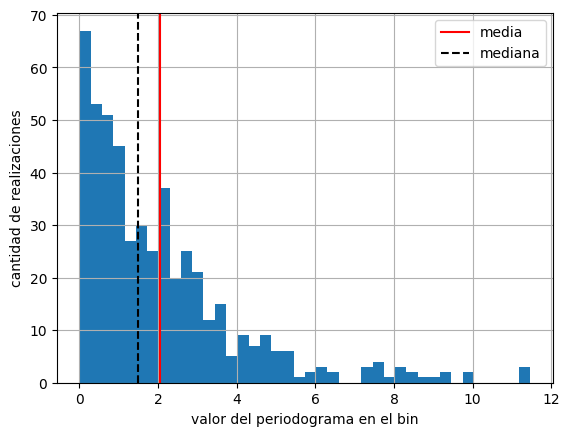

In [1]:
# G4 - Ejercicio 7: la varianza del periodograma no baja con N
import numpy as np
import matplotlib.pyplot as plt

sigma2 = 2.0
R = 500

def periodogramas(N, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, np.sqrt(sigma2), (R, N))       # R realizaciones de ruido blanco
    return np.abs(np.fft.fft(x, axis=1))**2 / N       # Ec. (14.15), una fila por realizacion

for N in [64, 256, 1024, 4096]:
    v = periodogramas(N)[:, N//4]                     # un bin cualquiera, lejos de w=0
    print(f"N={N:5d}  media={v.mean():.3f}  sesgo={v.mean()-sigma2:+.3f}  "
          f"varianza={v.var():.3f}  desvio={v.std():.3f}  mediana={np.median(v):.3f}")

v = periodogramas(1024)[:, 256]
plt.hist(v, bins=40)
plt.axvline(v.mean(), color="r", label="media")
plt.axvline(np.median(v), color="k", linestyle="--", label="mediana")
plt.xlabel("valor del periodograma en el bin")
plt.ylabel("cantidad de realizaciones")
plt.legend()
plt.grid(True)
plt.show()


G4: 7) a)

Valores en el bin N/4, sobre R = 500 realizaciones (sigma^2 = 2, PSD verdadera S_XX = 2):

| N | Media | Sesgo | Varianza | Desvio |
|---|---|---|---|---|
| 64 | 2.006 | +0.006 | 4.281 | 2.069 |
| 256 | 1.918 | -0.082 | 3.746 | 1.936 |
| 1024 | 2.055 | +0.055 | 4.126 | 2.031 |
| 4096 | 2.056 | +0.056 | 4.475 | 2.115 |

La media se queda pegada a 2 para todo N (el periodograma es asintoticamente insesgado y para ruido blanco ya lo es a N finito), pero la varianza no baja: se queda en ~4 = sigma^4, o sea desvio ~2 = sigma^2, tan grande como el valor que se quiere estimar. Aumentar N agrega mas bines de frecuencia, no mas promedio por bin: cada bin sigue siendo |X(w)|^2/N con dos grados de libertad (real e imaginaria gaussianas), asi que el periodograma es un estimador inconsistente. El histograma confirma la forma exponencial (chi-cuadrado con 2 g.l.): muy asimetrica, con mediana ~1.4 bastante por debajo de la media 2. Para reducir la varianza hay que promediar periodogramas o suavizar (Bartlett, Welch).

In [2]:
# G4 - Ejercicio 11: integrador con La440.wav
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as spsw
from scipy.io import wavfile
from scipy.signal import welch

fs, datos = wavfile.read("La440.wav")
if datos.ndim > 1:
    datos = datos[:, 0]                       # si es estereo, un solo canal
x = datos.astype(float)
x = x/np.max(np.abs(x))
print(f"fs = {fs} Hz, muestras = {len(x)}, duracion = {len(x)/fs:.2f} s")

# ---------- (a)-(b): amplitud de la fundamental con tres ventanas ----------
N = 4096
centro = len(x)//2
seg = x[centro - N//2:centro + N//2]        # tramo del medio, lejos del ataque
df = fs/N
k440 = 440*N/fs
print(f"df = {df:.3f} Hz, k(440) = {k440:.3f}, delta = {k440 - round(k440):+.3f} bins")
zona = (np.arange(N//2 + 1)*df > 400) & (np.arange(N//2 + 1)*df < 480)
for nombre, w in [("rectangular", spsw.boxcar(N)), ("hann", spsw.hann(N, sym=False)),
                  ("flattop", spsw.flattop(N, sym=False))]:
    X = np.abs(np.fft.rfft(seg*w))
    k = np.argmax(X*zona)
    a_hat = 2*X[k]/np.sum(w)
    print(f"  {nombre:12s} pico en {k*df:7.2f} Hz  amplitud = {a_hat:.4f}")

# ---------- (c): resolucion, sumando un tono de igual amplitud ----------
a_ref = 0.1            # REEMPLAZAR por la amplitud medida con flattop en (b)
f_extra = 450
plt.figure(figsize=(8, 4))
for nombre, generador, N_prueba in [("rectangular", spsw.boxcar, 2*fs//10),
                                    ("hann", spsw.hann, 4*fs//10)]:
    for factor in [0.5, 1.0]:
        Np = int(factor*N_prueba)
        tramo = x[centro - Np//2:centro - Np//2 + Np]
        n = np.arange(Np)
        y = tramo + a_ref*np.cos(2*np.pi*f_extra*n/fs)
        Y = np.abs(np.fft.rfft(y*generador(Np, sym=False), 2**18))
        f = np.fft.rfftfreq(2**18, d=1/fs)
        plt.plot(f, 20*np.log10(Y/Y.max()), label=f"{nombre}, N={Np}")
plt.xlim(400, 490)
plt.ylim(-50, 3)
plt.xlabel("Frecuencia [Hz]")
plt.legend()
plt.grid(True)

# ---------- (d)-(e): tono debil y piso de ruido ----------
A_debil_dB = -50       # respecto de la fundamental
f_debil = 660
n = np.arange(N)
y = seg + a_ref*10**(A_debil_dB/20)*np.cos(2*np.pi*f_debil*n/fs)
plt.figure(figsize=(8, 4))
for nombre, w in [("rectangular", spsw.boxcar(N)), ("hamming", spsw.hamming(N, sym=False)),
                  ("hann", spsw.hann(N, sym=False))]:
    Y = np.abs(np.fft.rfft(y*w, 8*N))
    f = np.fft.rfftfreq(8*N, d=1/fs)
    plt.plot(f, 20*np.log10(Y/Y.max()), label=nombre)
plt.xlim(300, 1000)
plt.ylim(-100, 3)
plt.axvline(f_debil, color="k", linestyle=":")
plt.xlabel("Frecuencia [Hz]")
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 4))
f_p = np.fft.rfftfreq(len(x), d=1/fs)
P = np.abs(np.fft.rfft(x))**2/len(x)
plt.plot(f_p, 10*np.log10(P/P.max() + 1e-20), alpha=0.5, label="periodograma, todo el archivo")
f_w, P_w = welch(x, fs=fs, window="hann", nperseg=N, noverlap=N//2, detrend=False)
plt.plot(f_w, 10*np.log10(P_w/P_w.max() + 1e-20), label=f"Welch, L={N}, 50%")
plt.xlim(0, 3000)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB respecto del maximo")
plt.legend()
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'La440.wav'